## XGBoost on MIMIC IV data

First let us load the data (already preprocessed on tabular_preprocessing.ipynb).

In [1]:
# Importing libraries
import ast
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack


In [12]:
# Load dataset
df = pd.read_csv("mimiciv_clinical_dataset_tabular_death_visit.csv")

# Count admission categories
admission_counts = df['admission_category'].value_counts()

# Display counts
print("Admission category counts:")
print(admission_counts := df['admission_category'].value_counts())

Admission category counts:
NORMAL       291667
EMERGENCY    254361
Name: admission_category, dtype: int64


In [10]:
df.head(3)

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
0,10000032,22595853,52,F,URGENT,EMERGENCY,HOME,1,52.0,0,32.0,50.0,0.0,0.0,8.0,"['Portal hypertension', 'Other ascites', 'Cirr...",1.0,['Percutaneous abdominal drainage'],14.0,"['Furosemide', 'Ipratropium Bromide Neb', 'Pot..."
1,10000032,22841357,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,25.0,0.0,0.0,8.0,['Unspecified viral hepatitis C with hepatic c...,1.0,['Percutaneous abdominal drainage'],15.0,"['Furosemide', 'Rifaximin', 'Sodium Chloride 0..."
2,10000032,29079034,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,11.0,1.0,0.0,13.0,"['Other iatrogenic hypotension', 'Chronic hepa...",0.0,None,24.0,"['Bisacodyl', 'Senna', 'Calcium Carbonate', 'R..."


In [11]:
patients = df['subject_id'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

train_df = df[df['subject_id'].isin(train_patients)].copy()
test_df = df[df['subject_id'].isin(test_patients)].copy()

In [5]:
# Be sure medication_list is a list, e.g.: ['Furosemide', 'Bisacodyl', ...]

def safe_convert(x):
    if pd.isna(x):
        return ''
    elif isinstance(x, list):
        return ' '.join(x)
    elif isinstance(x, str):
        try:
            x_eval = ast.literal_eval(x)
            if isinstance(x_eval, list):
                return ' '.join(x_eval)
            else:
                return ''
        except:
            return ''
    else:
        return ''

# Apply safely to each column:
train_df['med_text'] = train_df['medication_list'].apply(safe_convert)
train_df['diag_text'] = train_df['diagnosis_list'].apply(safe_convert)
train_df['proc_text'] = train_df['procedure_list'].apply(safe_convert)

test_df['med_text'] = test_df['medication_list'].apply(safe_convert)
test_df['diag_text'] = test_df['diagnosis_list'].apply(safe_convert)
test_df['proc_text'] = test_df['procedure_list'].apply(safe_convert)

In [6]:
# FIT CountVectorizer ONLY on training data (ClinicalBench style):
# Define CountVectorizer clearly, limit max features if needed:
med_vectorizer = CountVectorizer(max_features=1000, min_df=10)
diag_vectorizer = CountVectorizer(max_features=1000, min_df=10)
proc_vectorizer = CountVectorizer(max_features=1000, min_df=10)

# Fit on training only:
train_med = med_vectorizer.fit_transform(train_df['med_text'])
train_diag = diag_vectorizer.fit_transform(train_df['diag_text'])
train_proc = proc_vectorizer.fit_transform(train_df['proc_text'])

# Transform test data using fitted training vocabulary:
test_med = med_vectorizer.transform(test_df['med_text'])
test_diag = diag_vectorizer.transform(test_df['diag_text'])
test_proc = proc_vectorizer.transform(test_df['proc_text'])

In [28]:
# Combine sparse matrices horizontally (efficient):
X_train_sparse = sp.hstack([train_med, train_diag, train_proc])
X_test_sparse = sp.hstack([test_med, test_diag, test_proc])

# Convert sparse matrices to arrays if required (optional):
X_train = X_train_sparse.tocsr()
X_test = X_test_sparse.tocsr()

In [ ]:
numeric_features = ['age_at_event', 'icu_admissions', 'icu_days', 'num_diagnoses', 'num_procedures', 'num_medications']
train_numeric = train_df[numeric_features].values
test_numeric = test_df[numeric_features].values

# Final combined features:
X_train_final = hstack([X_train, train_numeric])
X_test_final = hstack([X_test, test_numeric])

In [33]:
# Defining target variable
y_train = (train_df['days_from_last_visit_to_death'] <= 90).astype(int).values
y_test = (test_df['days_from_last_visit_to_death'] <= 90).astype(int).values

In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train)

y_pred_proba = xgb_model.predict_proba(X_test_final)[:, 1]
y_pred = xgb_model.predict(X_test_final)

print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [18:06:59] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1727231492252/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.87      0.96      0.91     87208
           1       0.71      0.43      0.53     22076

    accuracy                           0.85    109284
   macro avg       0.79      0.69      0.72    109284
weighted avg       0.84      0.85      0.83    109284

AUC: 0.872


This approach however has a great limitation: we are not considering the longitudinality of data.
Let us implement here another approach based on Landmark. (TBD)

In [1]:
# Importing libraries
import ast
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# Load dataset
df = pd.read_csv("mimiciv_clinical_dataset_tabular_death_visit.csv")

# Count admission categories
admission_counts = df['admission_category'].value_counts()

# Display counts
print("Admission category counts:")
print(admission_counts := df['admission_category'].value_counts())

Admission category counts:
admission_category
NORMAL       291667
EMERGENCY    254361
Name: count, dtype: int64


In [5]:
df.head(10)

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
0,10000032,22595853,52,F,URGENT,EMERGENCY,HOME,1,52.0,0,32.0,50.0,0.0,0.0,8.0,"['Portal hypertension', 'Other ascites', 'Cirr...",1.0,['Percutaneous abdominal drainage'],14.0,"['Furosemide', 'Ipratropium Bromide Neb', 'Pot..."
1,10000032,22841357,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,25.0,0.0,0.0,8.0,['Unspecified viral hepatitis C with hepatic c...,1.0,['Percutaneous abdominal drainage'],15.0,"['Furosemide', 'Rifaximin', 'Sodium Chloride 0..."
2,10000032,29079034,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,11.0,1.0,0.0,13.0,"['Other iatrogenic hypotension', 'Chronic hepa...",0.0,None,24.0,"['Bisacodyl', 'Senna', 'Calcium Carbonate', 'R..."
3,10000032,25742920,52,F,EW EMER.,EMERGENCY,HOSPICE,1,52.0,0,32.0,-1.0,0.0,0.0,10.0,['Chronic hepatitis C without mention of hepat...,1.0,['Percutaneous abdominal drainage'],28.0,"['Sodium Chloride 0.9% Flush', '0.9% Sodium C..."
4,10000068,25022803,19,F,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,-1.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",1.0,['Other nonoperative respiratory measurements'],0.0,None
5,10000084,23052089,72,M,EW EMER.,EMERGENCY,HOME HEALTH CARE,1,73.0,0,46.0,32.0,0.0,0.0,6.0,"['Neurocognitive disorder with Lewy bodies', '...",0.0,None,13.0,"['Pramipexole', 'Pravastatin', 'rivastigmine',..."
6,10000084,29888819,72,M,EU OBSERVATION,NORMAL,NaN,1,73.0,0,46.0,-1.0,0.0,0.0,6.0,"['Altered mental status, unspecified', ""Parkin...",0.0,None,0.0,None
7,10000108,27250926,25,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,-1.0,0.0,0.0,2.0,['Cellulitis and abscess of oral soft tissues'...,0.0,None,0.0,None
8,10000117,22927623,55,F,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,672.0,0.0,0.0,9.0,"['Dysphagia, unspecified', 'Other specified sy...",0.0,None,2.0,"['Heparin', 'Sodium Chloride 0.9% Flush']"
9,10000117,27988844,57,F,OBSERVATION ADMIT,NORMAL,HOME HEALTH CARE,0,NaN,0,NaN,-1.0,0.0,0.0,13.0,['Unspecified intracapsular fracture of left f...,1.0,['Reposition Left Upper Femur with Internal Fi...,27.0,"['Iso-Osmotic Dextrose', 'CeFAZolin', 'Vitamin..."


In [6]:
import ast

def safe_join(x):
    if pd.isna(x) or x in ['[]', '', 'None']:
        return ''
    try:
        x_eval = ast.literal_eval(x)
        if isinstance(x_eval, list):
            return ' '.join(x_eval)
        else:
            return ''
    except:
        return ''

landmark_rows = []

#df = df.sort_values(['subject_id', 'hadm_id']).reset_index(drop=True) # That's not the right ordering!
# the dataset is still ordered, however we should consider a more robust way of doing so.


for patient_id, group in df.groupby('subject_id'):
    group = group.reset_index(drop=True)
    n_visits = group.shape[0]

    for landmark_idx in range(n_visits):
        current_visit = group.iloc[landmark_idx]
        past_visits = group.iloc[:landmark_idx + 1]

        meds_text = ' '.join(past_visits['medication_list'].apply(safe_join))
        diag_text = ' '.join(past_visits['diagnosis_list'].apply(safe_join))
        proc_text = ' '.join(past_visits['procedure_list'].apply(safe_join))

        # Define outcome
        days_to_death = current_visit['days_from_last_visit_to_death']
        death_in_90days = 1 if (not np.isnan(days_to_death) and days_to_death <= 90) else 0

        landmark_rows.append({
            'subject_id': current_visit['subject_id'],
            'landmark_visit': landmark_idx + 1,
            'age_at_landmark': current_visit['age_at_event'],
            'gender': current_visit['gender'],
            'num_total_visits': landmark_idx + 1,
            'days_from_last_visit': current_visit['days_until_next_visit'],
            'death_in_90days': death_in_90days,
            'med_text': meds_text,
            'diag_text': diag_text,
            'proc_text': proc_text
        })

landmark_df = pd.DataFrame(landmark_rows)

In [7]:
landmark_df.head(10)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text
0,10000032,1,52,F,1,50.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage
1,10000032,2,52,F,2,25.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...
2,10000032,3,52,F,3,11.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...
3,10000032,4,52,F,4,-1.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...
4,10000068,1,19,F,1,-1.0,0,,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements
5,10000084,1,72,M,1,32.0,1,Pramipexole Pravastatin rivastigmine Senna QUE...,Neurocognitive disorder with Lewy bodies Demen...,
6,10000084,2,72,M,2,-1.0,1,Pramipexole Pravastatin rivastigmine Senna QUE...,Neurocognitive disorder with Lewy bodies Demen...,
7,10000108,1,25,M,1,-1.0,0,,Cellulitis and abscess of oral soft tissues Ot...,
8,10000117,1,55,F,1,672.0,0,Heparin Sodium Chloride 0.9% Flush,"Dysphagia, unspecified Other specified symptom...",
9,10000117,2,57,F,2,-1.0,0,Heparin Sodium Chloride 0.9% Flush Iso-Osmoti...,"Dysphagia, unspecified Other specified symptom...",Reposition Left Upper Femur with Internal Fix...


In [8]:
# Convert gender explicitly into binary numeric values
landmark_df['gender_numeric'] = landmark_df['gender'].map({'F': 0, 'M': 1})
landmark_df.head(5)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text,gender_numeric
0,10000032,1,52,F,1,50.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage,0
1,10000032,2,52,F,2,25.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
2,10000032,3,52,F,3,11.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
3,10000032,4,52,F,4,-1.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
4,10000068,1,19,F,1,-1.0,0,,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements,0


In [9]:
landmark_df.to_csv('landmark_df.csv', index=False, na_rep = 'Unknown')

### Patient-level Train/Test Split on Landmark dataset

In [7]:
landmark_df = pd.read_csv("landmark_df.csv")

In [8]:
# Separate patients at Landmark 1 into two categories
landmark1_df = landmark_df[landmark_df['landmark_visit'] == 1].copy()

# Identify single vs. multi-visit patients
visit_counts = landmark_df['subject_id'].value_counts()
single_visit_patients = visit_counts[visit_counts == 1].index
multi_visit_patients = visit_counts[visit_counts > 1].index

single_visit_df = landmark1_df[landmark1_df['subject_id'].isin(single_visit_patients)].copy()
multi_visit_df = landmark1_df[landmark1_df['subject_id'].isin(multi_visit_patients)].copy()

def compute_auc(subset_df):
    patients = subset_df['subject_id'].unique()
    train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

    train_df = subset_df[subset_df['subject_id'].isin(train_patients)].copy()
    test_df = subset_df[subset_df['subject_id'].isin(test_patients)].copy()

    if len(np.unique(test_df['death_in_90days'])) < 2:
        print("Single class present in test set; skipping AUC calculation.")
        auc = np.nan
    else:
        med_vectorizer = CountVectorizer(max_features=1000, min_df=1)
        diag_vectorizer = CountVectorizer(max_features=1000, min_df=1)
        proc_vectorizer = CountVectorizer(max_features=1000, min_df=1)

        train_med_vec = med_vectorizer.fit_transform(train_df['med_text'])
        test_med_vec = med_vectorizer.transform(test_df['med_text'])

        train_diag_vec = diag_vectorizer.fit_transform(train_df['diag_text'])
        test_diag_vec = diag_vectorizer.transform(test_df['diag_text'])

        train_proc_vec = proc_vectorizer.fit_transform(train_df['proc_text'])
        test_proc_vec = proc_vectorizer.transform(test_df['proc_text'])

        numeric_features = ['age_at_landmark', 'landmark_visit', 
                            'num_total_visits', 'days_from_last_visit', 'gender_numeric']

        X_train_numeric = train_df[numeric_features].values
        X_test_numeric = test_df[numeric_features].values

        X_train = hstack([train_med_vec, train_diag_vec, train_proc_vec, X_train_numeric])
        X_test = hstack([test_med_vec, test_diag_vec, test_proc_vec, X_test_numeric])

        y_train = train_df['death_in_90days'].values
        y_test = test_df['death_in_90days'].values

        model = xgb.XGBClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)

    mortality_rate = np.mean(subset_df['death_in_90days']) * 100
    num_patients = len(subset_df)

    return num_patients, mortality_rate, auc

# Computing results for single-visit patients
single_num_patients, single_mortality, single_auc = compute_auc(single_visit_df)

# Computing results for multi-visit patients
multi_num_patients, multi_mortality, multi_auc = compute_auc(multi_visit_df)

# Results summary DataFrame
results_subgroup_df = pd.DataFrame({
    'Patient Subgroup': ['Single Visit', 'Multiple Visits'],
    'Number of Patients': [single_num_patients, multi_num_patients],
    'Mortality (%)': [f"{single_mortality:.1f}%", f"{multi_mortality:.1f}%"],
    'AUC XGBoost': [round(single_auc, 3), round(multi_auc, 3)]
})

print(results_subgroup_df)

  Patient Subgroup  Number of Patients Mortality (%)  AUC XGBoost
0     Single Visit              123289          8.1%        0.966
1  Multiple Visits              100163         16.6%        0.826


In [ ]:
# ---- INSERT STEP 1 HERE (loop through landmarks) ----
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

numeric_features = ['age_at_landmark', 'landmark_visit', 
                    'num_total_visits', 'days_from_last_visit', 'gender_numeric']

results = []

for landmark_visit in range(1,11):
    df_subset = landmark_df[landmark_df['landmark_visit'] == landmark_visit]

    patients = df_subset['subject_id'].unique()
    train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

    train_df = df_subset[df_subset['subject_id'].isin(train_patients)].copy()
    test_df = df_subset[df_subset['subject_id'].isin(test_patients)].copy()

    if train_df.empty or test_df.empty:
        continue

    # Text Vectorizers (initialize for each landmark separately)
    med_vectorizer = CountVectorizer(max_features=1000, min_df=10)
    diag_vectorizer = CountVectorizer(max_features=1000, min_df=10)
    proc_vectorizer = CountVectorizer(max_features=1000, min_df=10)

    train_med_vec = med_vectorizer.fit_transform(train_df['med_text'])
    test_med_vec = med_vectorizer.transform(test_df['med_text'])

    train_diag_vec = diag_vectorizer.fit_transform(train_df['diag_text'])
    test_diag_vec = diag_vectorizer.transform(test_df['diag_text'])

    train_proc_vec = proc_vectorizer.fit_transform(train_df['proc_text'])
    test_proc_vec = proc_vectorizer.transform(test_df['proc_text'])

    # Numeric features
    X_train_numeric = train_df[numeric_features].values
    X_test_numeric = test_df[numeric_features].values

    # Combine features
    X_train = hstack([train_med_vec, train_diag_vec, train_proc_vec, X_train_numeric])
    X_test = hstack([test_med_vec, test_diag_vec, test_proc_vec, X_test_numeric])

    y_train = train_df['death_in_90days'].values
    y_test = test_df['death_in_90days'].values

    # Train model
    model = xgb.XGBClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred_proba = model.predict_proba(X_test)[:,1]

    # Check if both classes are present
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = np.nan  # or set auc = None or skip appending this result
        print(f"Landmark visit {landmark_visit}: Only one class present in test set. AUC set to NaN.")

    mortality_rate = np.mean(y_test) * 100
    num_patients = len(df_subset)

    results.append({
        'Landmark (Visit Number)': landmark_visit,
        'Number of Patients': num_patients,
        'Mortality (%)': f"{mortality_rate:.1f}%",
        'AUC XGBoost': round(auc, 3)
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results).sort_values('Landmark (Visit Number)')
print(results_df)

   Landmark (Visit Number)  Number of Patients Mortality (%)  AUC XGBoost
0                        1              223452         12.0%        0.915
1                        2              100163         16.8%        0.881
2                        3               56040         21.7%        0.861
3                        4               35932         26.4%        0.847
4                        5               24760         28.0%        0.829
5                        6               18131         31.1%        0.806
6                        7               13819         32.9%        0.823
7                        8               10855         33.8%        0.794
8                        9                8668         37.0%        0.793
9                       10                7017         35.7%        0.792


1. Mortality Trend (Increasing Risk with Visits):
	* Mortality consistently increases with each additional hospital visit, from 12% at the first visit (baseline) to approximately 35-37% at later visits.
	* This clearly indicates that patients with multiple hospitalizations represent a higher-risk subgroup, experiencing worse outcomes over time.

2. Number of Patients Decreasing:
	* The number of patients available at each subsequent landmark decreases significantly from 223,452 at the first landmark to just 7,017 by the 10th landmark.
	* This drop reflects patient attrition, mainly due to death or fewer patients experiencing frequent hospital readmissions. Such attrition is common in real-world hospital data.

3. Model Performance (AUC):
	* At baseline (first visit), the XGBoost model achieves a high predictive performance (AUC = 0.915). This indicates that early visits provide rich information enabling accurate mortality prediction.
	* Model performance gradually decreases over subsequent visits (from 0.915 to about 0.79-0.80). Although still high, predictive ability declines as landmarks progress.
	* The decline in performance could be explained by:
	* Fewer available patients at higher landmarks reducing the model’s ability to learn generalizable patterns.
	* Increasing complexity or heterogeneity in clinical histories at higher landmark points.
	* The slight increase in AUC at landmark 7 (0.823) compared to landmark 6 (0.806) may reflect variability due to smaller sample sizes, or specific clinical characteristics at that stage. It doesn’t significantly affect the overall declining trend.

#### Possible Clinical Interpretation:
* Early hospitalizations (baseline visits) provide the best predictive opportunity for identifying high-risk patients.
* Later visits, despite higher mortality rates, pose challenges for prediction—patients become more complex, and sample sizes become smaller.

Clinically, this underscores the importance of leveraging early patient interactions to predict and potentially intervene in high-risk scenarios.

However one should be aware that in this case we are mixing up patients with different clinical histories. Clearly, in landmark 1 we have all the patients. So, the data presented here is not really stratified per patients, but, per landmark. To see whether increasing the number of landmark we get a better predictive performance we should consider only patients with the same number of visit.

Indeed:
At Landmark 1 (Baseline), we currently have all patients, including:
* Patients who have only one visit (no further visits).
* Patients who have multiple visits (appear again at Landmark 2, 3, etc.).
* At subsequent landmarks (2, 3, ..., 10), you have only patients with multiple visits who survived to reach these additional visits. This naturally creates a changing and potentially confusing cohort composition across landmarks.

This could be a risk, since:
* The group of patients at Landmark 1 is heterogeneous, combining:
* Patients with stable or mild conditions who might never need another hospitalization.
* Patients with severe or chronic conditions who repeatedly require hospital care and appear at subsequent landmarks.
* This creates a potential selection bias, since the patient population at each landmark differs significantly:
* Landmark 1 represents a broader, more general cohort.
* Later landmarks represent subsets of increasingly selected patients (sicker or chronically ill).
* Thus, comparing mortality rates or predictive performance directly across landmarks could be misleading without clearly acknowledging this difference in cohort composition.

In [ ]:
# First ensure you have all required imports:
# import pandas as pd
# import numpy as np
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import roc_auc_score
# from sklearn.feature_extraction.text import CountVectorizer
# from scipy.sparse import hstack

# landmark_df = pd.read_csv("landmark_df.csv")

# # Ensure your DataFrame is sorted by patient and landmark_visit
# landmark_df = landmark_df.sort_values(['subject_id', 'landmark_visit']).reset_index(drop=True)

# # Function to perform transformation
# def transform_to_past_variable(group):
#     group = group.sort_values('landmark_visit').copy()
#     # Shift the values down (future to past)
#     group['days_since_last_visit'] = group['days_from_last_visit'].shift(1)
#     # First landmark always has -1
#     group['days_since_last_visit'].iloc[0] = -1
#     return group

# # Apply the transformation per patient
# landmark_df = landmark_df.groupby('subject_id').apply(transform_to_past_variable).reset_index(drop=True)

# # Drop the original future-looking column (optional but strongly recommended)
# landmark_df.drop(columns=['days_from_last_visit'], inplace=True)

# # Check the result clearly
# print(landmark_df[['subject_id', 'landmark_visit', 'days_since_last_visit']].head(15))

    subject_id  landmark_visit  days_since_last_visit
0     10000032               1                   -1.0
1     10000032               2                   50.0
2     10000032               3                   25.0
3     10000032               4                   11.0
4     10000068               1                   -1.0
5     10000084               1                   -1.0
6     10000084               2                   32.0
7     10000108               1                   -1.0
8     10000117               1                   -1.0
9     10000117               2                  672.0
10    10000161               1                   -1.0
11    10000248               1                   -1.0
12    10000280               1                   -1.0
13    10000560               1                   -1.0
14    10000635               1                   -1.0


In [ ]:
#landmark_df = landmark_df.rename(columns={'days_since_last_visit':'days_since_previous_visit'})
#landmark_df.head(10)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,death_in_90days,med_text,diag_text,proc_text,gender_numeric,days_since_previous_visit
0,10000032,1,52,F,1,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage,0,-1.0
1,10000032,2,52,F,2,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0,50.0
2,10000032,3,52,F,3,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0,25.0
3,10000032,4,52,F,4,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0,11.0
4,10000068,1,19,F,1,0,Unknown,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements,0,-1.0
5,10000084,1,72,M,1,1,Pramipexole Pravastatin rivastigmine Senna QUE...,Neurocognitive disorder with Lewy bodies Demen...,Unknown,1,-1.0
6,10000084,2,72,M,2,1,Pramipexole Pravastatin rivastigmine Senna QUE...,Neurocognitive disorder with Lewy bodies Demen...,,1,32.0
7,10000108,1,25,M,1,0,Unknown,Cellulitis and abscess of oral soft tissues Ot...,Unknown,1,-1.0
8,10000117,1,55,F,1,0,Heparin Sodium Chloride 0.9% Flush,"Dysphagia, unspecified Other specified symptom...",Unknown,0,-1.0
9,10000117,2,57,F,2,0,Heparin Sodium Chloride 0.9% Flush Iso-Osmoti...,"Dysphagia, unspecified Other specified symptom...",Reposition Left Upper Femur with Internal Fix...,0,672.0


In [ ]:
# landmark_df.to_csv('landmark_df.csv', index=False, na_rep = 'Unknown')

In [26]:
# First ensure you have all required imports:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack

landmark_df = pd.read_csv("landmark_df.csv") # there is not anymore variable with data leakage (no more days_from_last_visit but days_since_previous_visit)

max_visits = 1  # Modify this for different visit numbers

# Identify patients with exactly 'max_visits' visits
visit_counts = landmark_df['subject_id'].value_counts()
selected_patients = visit_counts[visit_counts == max_visits].index

# Subset your landmark dataframe
df_selected = landmark_df[landmark_df['subject_id'].isin(selected_patients)]

results = []
numeric_features = ['age_at_landmark', 'landmark_visit', 
                    'num_total_visits', 'days_since_previous_visit', 'gender_numeric']

for landmark_visit in range(1, max_visits + 1):
    df_subset = df_selected[df_selected['landmark_visit'] == landmark_visit]

    patients = df_subset['subject_id'].unique()
    train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

    train_df = df_subset[df_subset['subject_id'].isin(train_patients)].copy()
    test_df = df_subset[df_subset['subject_id'].isin(test_patients)].copy()

    if train_df.empty or test_df.empty or len(np.unique(test_df['death_in_90days'])) < 2:
        continue

    med_vectorizer = CountVectorizer(max_features=1000, min_df=1)
    diag_vectorizer = CountVectorizer(max_features=1000, min_df=1)
    proc_vectorizer = CountVectorizer(max_features=1000, min_df=1)

    train_med_vec = med_vectorizer.fit_transform(train_df['med_text'])
    test_med_vec = med_vectorizer.transform(test_df['med_text'])

    train_diag_vec = diag_vectorizer.fit_transform(train_df['diag_text'])
    test_diag_vec = diag_vectorizer.transform(test_df['diag_text'])

    train_proc_vec = proc_vectorizer.fit_transform(train_df['proc_text'])
    test_proc_vec = proc_vectorizer.transform(test_df['proc_text'])

    X_train_numeric = train_df[numeric_features].values
    X_test_numeric = test_df[numeric_features].values

    X_train = hstack([train_med_vec, train_diag_vec, train_proc_vec, X_train_numeric])
    X_test = hstack([test_med_vec, test_diag_vec, test_proc_vec, X_test_numeric])

    y_train = train_df['death_in_90days'].values
    y_test = test_df['death_in_90days'].values

    model = xgb.XGBClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_pred_proba)

    mortality_rate = np.mean(y_test) * 100
    num_patients = len(df_subset)

    results.append({
        'Landmark (Visit Number)': landmark_visit,
        'Number of Patients': num_patients,
        'Mortality (%)': f"{mortality_rate:.1f}%",
        'AUC XGBoost': f"{auc:.4}"
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


   Landmark (Visit Number)  Number of Patients Mortality (%) AUC XGBoost
0                        1              123289          8.1%      0.9661


In [6]:
landmark_df = pd.read_csv("landmark_df.csv")
patients = landmark_df['subject_id'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

train_df = landmark_df[landmark_df['subject_id'].isin(train_patients)].copy()
test_df = landmark_df[landmark_df['subject_id'].isin(test_patients)].copy()

In [7]:
landmark_df.head(5)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text,gender_numeric
0,10000032,1,52,F,1,50.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage,0
1,10000032,2,52,F,2,25.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
2,10000032,3,52,F,3,11.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
3,10000032,4,52,F,4,-1.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
4,10000068,1,19,F,1,-1.0,0,Unknown,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements,0


In [8]:
train_df.head(5)

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text,gender_numeric
0,10000032,1,52,F,1,50.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage,0
1,10000032,2,52,F,2,25.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
2,10000032,3,52,F,3,11.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
3,10000032,4,52,F,4,-1.0,1,Furosemide Ipratropium Bromide Neb Potassium C...,Portal hypertension Other ascites Cirrhosis of...,Percutaneous abdominal drainage Percutaneous a...,0
4,10000068,1,19,F,1,-1.0,0,Unknown,"Alcohol abuse, unspecified",Other nonoperative respiratory measurements,0


### Apply CountVectorizer only on training portion

In [5]:
# Vectorizer for medications
# TODO: Is it correct?
med_vectorizer = CountVectorizer(max_features=1000, min_df=10)
train_med_vec = med_vectorizer.fit_transform(train_df['med_text'])
test_med_vec = med_vectorizer.transform(test_df['med_text'])

# Vectorizer for diagnoses
# TODO: Is it correct?
diag_vectorizer = CountVectorizer(max_features=1000, min_df=10)
train_diag_vec = diag_vectorizer.fit_transform(train_df['diag_text'])
test_diag_vec = diag_vectorizer.transform(test_df['diag_text'])

# Vectorizer for procedures
# TODO: Is it correct?
proc_vectorizer = CountVectorizer(max_features=1000, min_df=10)
train_proc_vec = proc_vectorizer.fit_transform(train_df['proc_text'])
test_proc_vec = proc_vectorizer.transform(test_df['proc_text'])

# numeric features (age, gender, etc.)
numeric_features = ['age_at_landmark',
                    'landmark_visit',
                    'num_total_visits',
                    'days_from_last_visit',
                    'gender_numeric']
X_train_numeric = train_df[numeric_features].values
X_test_numeric = test_df[numeric_features].values

# Combine all features (sparse + numeric)
X_train = hstack([train_med_vec, train_diag_vec, train_proc_vec, X_train_numeric])
X_test = hstack([test_med_vec, test_diag_vec, test_proc_vec, X_test_numeric])

y_train = train_df['death_in_90days'].values
y_test = test_df['death_in_90days'].values

### Train XGBoost model on the LandMark Dataset

In [7]:
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

In [8]:
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     87208
           1       0.69      0.48      0.57     22076

    accuracy                           0.85    109284
   macro avg       0.78      0.71      0.74    109284
weighted avg       0.84      0.85      0.84    109284

AUC: 0.8864731377572675


### Visualization

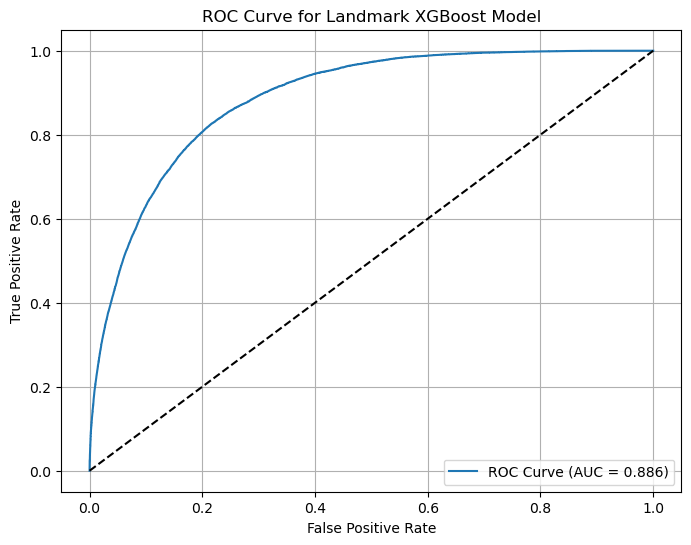

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Landmark XGBoost Model')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [43]:
# pick a sample patient explicitly to illustrate clearly
example_patient = landmark_df[landmark_df['subject_id'] == landmark_df['subject_id'].iloc[0]]

print(f"Patient ID: {example_patient['subject_id'].iloc[0]}")
print("\nLandmark Evolution (Clinical History):\n")

for idx, row in example_patient.iterrows():
    print(f"Landmark Visit: {row['landmark_visit']}")
    print(f" - Age at landmark: {row['age_at_landmark']}")
    print(f" - Gender: {row['gender']}")
    print(f" - Total visits so far: {row['num_total_visits']}")
    print(f" - Days from last visit: {row['days_from_last_visit']}")
    print(f" - Medications so far: {row['med_text'][:100]}{'...' if len(row['med_text']) > 100 else ''}")
    print(f" - Diagnoses so far: {row['diag_text'][:100]}{'...' if len(row['diag_text']) > 100 else ''}")
    print(f" - Procedures so far: {row['proc_text'][:100]}{'...' if len(row['proc_text']) > 100 else ''}")
    print(f" - Death within 90 days after landmark: {'Yes' if row['death_in_90days'] else 'No'}\n")

Patient ID: 10000032

Landmark Evolution (Clinical History):

Landmark Visit: 1
 - Age at landmark: 52
 - Gender: F
 - Total visits so far: 1
 - Days from last visit: 50.0
 - Medications so far: Furosemide Ipratropium Bromide Neb Potassium Chloride Sodium Chloride 0.9%  Flush Raltegravir Spiron...
 - Diagnoses so far: Portal hypertension Other ascites Cirrhosis of liver without mention of alcohol Unspecified viral he...
 - Procedures so far: Percutaneous abdominal drainage
 - Death within 90 days after landmark: Yes

Landmark Visit: 2
 - Age at landmark: 52
 - Gender: F
 - Total visits so far: 2
 - Days from last visit: 25.0
 - Medications so far: Furosemide Ipratropium Bromide Neb Potassium Chloride Sodium Chloride 0.9%  Flush Raltegravir Spiron...
 - Diagnoses so far: Portal hypertension Other ascites Cirrhosis of liver without mention of alcohol Unspecified viral he...
 - Procedures so far: Percutaneous abdominal drainage Percutaneous abdominal drainage
 - Death within 90 days after

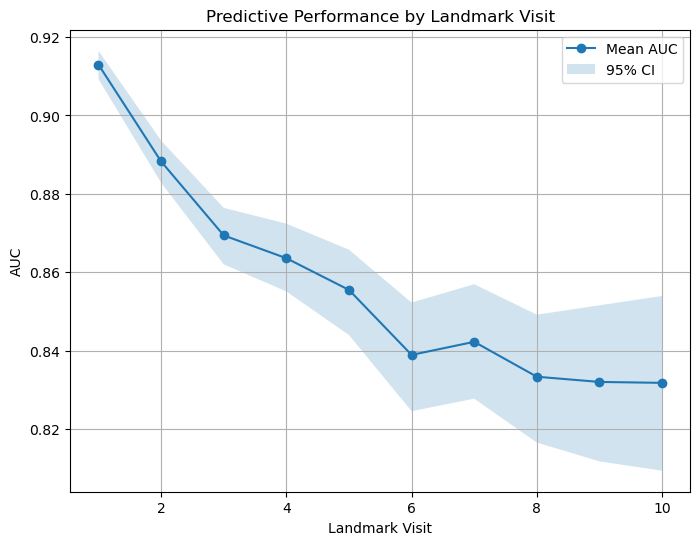

In [10]:
import warnings
# Just explicitly reset test_df indices clearly:
test_df = test_df.reset_index(drop=True)

# convert X_test explicitly for indexing:
X_test_csr = X_test.tocsr()

landmarks = sorted(test_df['landmark_visit'].unique())
mean_auc = []
lower_ci = []
upper_ci = []
valid_landmarks = []

for landmark in range(1, 11):
    subset = test_df[test_df['landmark_visit'] == landmark]

    if len(subset) == 0:
        continue  # explicitly skip empty subsets

    preds = model.predict_proba(X_test_csr[subset.index.values])[:, 1]
    true_labels = subset['death_in_90days'].values

    # Explicitly check if both classes exist:
    if len(np.unique(true_labels)) < 2:
        warnings.warn(f"Skipping landmark {landmark}: Only one class present in true labels.")
        continue  # skip this landmark explicitly

    auc = roc_auc_score(true_labels, preds)
    mean_auc.append(auc)
    valid_landmarks.append(landmark)

    # Bootstrap explicitly confidence intervals:
    bootstrapped_scores = []
    np.random.seed(42)
    for _ in range(1000):
        indices = np.random.choice(len(preds), len(preds), replace=True)
        if len(np.unique(true_labels[indices])) < 2:
            continue
        bootstrapped_scores.append(roc_auc_score(true_labels[indices], preds[indices]))

    sorted_scores = np.sort(bootstrapped_scores)
    lower_ci.append(sorted_scores[int(0.025 * len(sorted_scores))])
    upper_ci.append(sorted_scores[int(0.975 * len(sorted_scores))])

# Explicit plotting clearly:
plt.figure(figsize=(8,6))
plt.plot(valid_landmarks, mean_auc, marker='o', label='Mean AUC')
plt.fill_between(valid_landmarks, lower_ci, upper_ci, alpha=0.2, label='95% CI')
plt.xlabel('Landmark Visit')
plt.ylabel('AUC')
plt.title('Predictive Performance by Landmark Visit')
plt.grid()
plt.legend()
plt.show()

In this graph we can see that there could be some issues, meaning that, increasing the landmark visit we get lower performance (lower AUC). However here we could just mixing up things. Indeed we have way more patients with only one visits. Should we plot this graph only for patients that have at least a number of Landmark equal to the last value of x-axis?
Let us try to fix that.

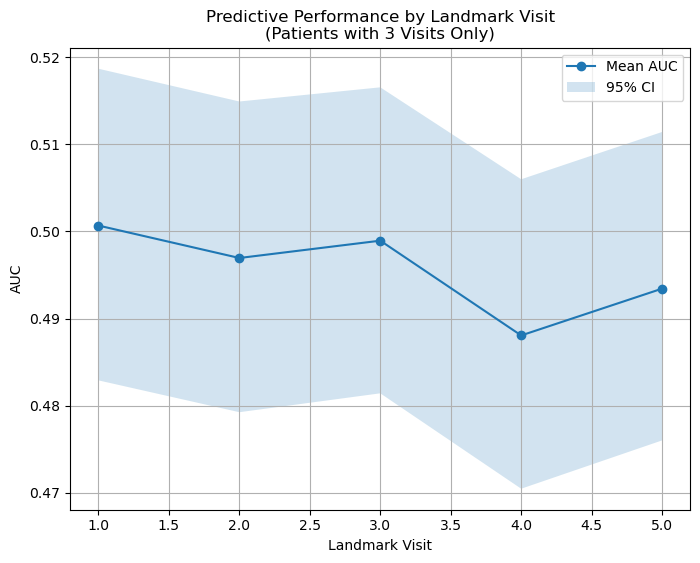

In [12]:
# explicitly select only patients with at least 5 visits:
max_landmark = 5
patients_longitudinal = test_df.groupby('subject_id').filter(lambda x: len(x) >= max_landmark)

# Reset indices explicitly to match features again:
patients_longitudinal = patients_longitudinal.reset_index(drop=True)

X_test_longitudinal = X_test.tocsr()[patients_longitudinal.index.values]

landmarks = list(range(1, max_landmark+1))
mean_auc, lower_ci, upper_ci = [], [], []

for landmark in landmarks:
    subset = patients_longitudinal[patients_longitudinal['landmark_visit'] == landmark]

    preds = model.predict_proba(X_test_longitudinal[subset.index.values])[:, 1]
    true_labels = subset['death_in_90days'].values

    # skip if only one class explicitly (unlikely here, but safe):
    if len(np.unique(true_labels)) < 2:
        continue

    auc = roc_auc_score(true_labels, preds)
    mean_auc.append(auc)

    # Bootstrap explicitly for confidence intervals:
    bootstrapped_scores = []
    np.random.seed(42)
    for _ in range(10000):
        indices = np.random.choice(len(preds), len(preds), replace=True)
        if len(np.unique(true_labels[indices])) < 2:
            continue
        bootstrapped_scores.append(roc_auc_score(true_labels[indices], preds[indices]))

    sorted_scores = np.sort(bootstrapped_scores)
    lower_ci.append(sorted_scores[int(0.025 * len(sorted_scores))])
    upper_ci.append(sorted_scores[int(0.975 * len(sorted_scores))])

# Explicit plotting clearly:
plt.figure(figsize=(8,6))
plt.plot(landmarks, mean_auc, marker='o', label='Mean AUC')
plt.fill_between(landmarks, lower_ci, upper_ci, alpha=0.2, label='95% CI')
plt.xlabel('Landmark Visit')
plt.ylabel('AUC')
plt.title('Predictive Performance by Landmark Visit\n(Patients with 3 Visits Only)')
plt.grid()
plt.legend()
plt.show()

let us explore further how our patients are looking in this case:

In [46]:
patients_longitudinal

,subject_id,landmark_visit,age_at_landmark,gender,num_total_visits,days_from_last_visit,death_in_90days,med_text,diag_text,proc_text,gender_numeric
0,10001186,1,46,F,1,23.0,0,Sodium Chloride 0.9% Flush Ondansetron Guaife...,Disruption of external operation (surgical) wo...,Removal of skull plate,0
1,10001186,2,46,F,2,635.0,0,Sodium Chloride 0.9% Flush Ondansetron Guaife...,Disruption of external operation (surgical) wo...,Removal of skull plate Other skin graft to oth...,0
2,10001186,3,48,F,3,-1.0,0,Sodium Chloride 0.9% Flush Ondansetron Guaife...,Disruption of external operation (surgical) wo...,Removal of skull plate Other skin graft to oth...,0
3,10001319,1,29,F,1,458.0,0,Ibuprofen Oxycodone-Acetaminophen Bisacodyl Di...,"First-degree perineal laceration, delivered, w...",Repair of other current obstetric laceration,0
4,10001319,2,30,F,2,1206.0,0,Ibuprofen Oxycodone-Acetaminophen Bisacodyl Di...,"First-degree perineal laceration, delivered, w...",Repair of other current obstetric laceration O...,0
...,...,...,...,...,...,...,...,...,...,...,...
11719,19991805,2,84,F,2,109.0,1,Influenza Vaccine Quadrivalent Dextrose 5% Cl...,"Nausea with vomiting Abdominal pain, unspecifi...",,0
11720,19991805,3,85,F,3,-1.0,1,Influenza Vaccine Quadrivalent Dextrose 5% Cl...,"Nausea with vomiting Abdominal pain, unspecifi...",,0
11721,19997062,1,50,M,1,2678.0,0,Oxycodone-Acetaminophen Heparin NS (Mini Bag P...,Calculus of gallbladder with acute cholecystit...,Laparoscopic cholecystectomy Laparoscopic live...,1
11722,19997062,2,58,M,2,817.0,0,Oxycodone-Acetaminophen Heparin NS (Mini Bag P...,Calculus of gallbladder with acute cholecystit...,Laparoscopic cholecystectomy Laparoscopic live...,1
